# Arya Phones — Market Simulation

Simulates how **price**, **supplier selection**, and **admin Beta distribution** interact in the MNL demand model.

## Experiments
1. **Single-team frictionless** — effect of price across all feasible sets
2. **Admin distribution effect** — same selections, 5 Beta shapes
3. **Two-team price war** — Team A vs Team B, grid of prices
4. **Two-team Beta sweep** — fixed prices, 5 Beta shapes
5. **Three-team full factorial** — random mix of strategies
6. **Delta (price sensitivity) sweep** — how calibration changes everything

Results are exported to `market_simulation_results.xlsx`.

In [43]:
import sys
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path('../..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from server.app.service import get_tables
from server.app.optimization_controller import manual_metrics, MaxProfitConfig
from server.app.settings import FIXED_POLICY, GAME_SETTINGS
from server.app.beta_density import BetaDensity
from server.app.mnl_market import BuyerProfile, run_mnl_market
from server.app.customer_segment import CustomerSegment

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

suppliers_df, users_df = get_tables()
N = len(users_df)
print(f'Suppliers: {len(suppliers_df)}  |  User segments: {N}')
print(f'IDs: {sorted(suppliers_df["supplier_id"].tolist())}')


Project root: C:\Users\LENOVO\Desktop\Asistan\Arya Phone\arya_fullstack_app
Suppliers: 18  |  User segments: 20
IDs: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R']


In [44]:
# ?? Scenario parameters ??????????????????????????????????????????????????????

SUPPLIER_SETS = {
    '[P]':     ['P'],
    '[P,O]':   ['P', 'O'],
    '[P,O,N]': ['P', 'O', 'N'],
    '[P,N]':   ['P', 'N'],       # infeasible ? env constraint violated
    '[P,N,I]': ['P', 'N', 'I'],
}

PRICES = [60, 70, 80, 90, 100, 110, 120, 130, 140]

BETA_CONFIGS = {
    'Uniform (1,1)':          (1.0, 1.0),
    'Bell/Symmetric (3,3)':   (3.0, 3.0),
    'Quality-pref (1.5,5)':   (1.5, 5.0),
    'Price-pref (5,1.5)':     (5.0, 1.5),
    'U-shape (0.5,0.5)':      (0.5, 0.5),
}

TEAM_COLORS = {
    'Budget [P]': '#4C78A8',
    'Value [P,N,I]': '#F58518',
    'Premium [P,O,N]': '#54A24B',
}

PREFERENCE_COLS = [
    'w_cost',
    'w_env',
    'w_social',
    'w_strategic',
    'w_improvement',
    'w_low_quality',
]

PREFERENCE_LABELS = {
    'w_cost': 'Cost sensitive',
    'w_env': 'Environment first',
    'w_social': 'Social impact',
    'w_strategic': 'Strategic value',
    'w_improvement': 'Improvement upside',
    'w_low_quality': 'Quality risk avoidance',
}

PREFERENCE_COLORS = {
    'Cost sensitive': '#4C78A8',
    'Environment first': '#72B7B2',
    'Social impact': '#E45756',
    'Strategic value': '#9D755D',
    'Improvement upside': '#B279A2',
    'Quality risk avoidance': '#FF9DA6',
}

# ?? Helper functions ?????????????????????????????????????????????????????????

def cfg(price=100.0):
    """Build a MaxProfitConfig with given price."""
    return MaxProfitConfig(
        price_per_user=float(price),
        cost_scale=GAME_SETTINGS.cost_scale,
        env_cap=GAME_SETTINGS.env_cap,
        social_cap=GAME_SETTINGS.social_cap,
    )

def make_segments(alpha=3.0, beta=3.0):
    """Build CustomerSegment list from users_df sorted by w_cost, weighted by Beta(alpha,beta)."""
    bd = BetaDensity(alpha=max(0.01, alpha), beta=max(0.01, beta))
    us = users_df.sort_values('w_cost').reset_index(drop=True)
    return [
        CustomerSegment(
            segment_id=str(row['user_id']),
            density=float(bd.density_at((i + 0.5) / N)),
            w_env=float(row.get('w_env', 0)),
            w_social=float(row.get('w_social', 0)),
            w_cost=float(row.get('w_cost', 1)),
            w_strategic=float(row.get('w_strategic', 0)),
            w_improvement=float(row.get('w_improvement', 0)),
            w_low_quality=float(row.get('w_low_quality', 0)),
        )
        for i, (_, row) in enumerate(us.iterrows())
    ]

def build_segment_table(alpha=3.0, beta=3.0, distribution_name=None):
    """Return segment metadata with normalized Beta weights for plotting/export."""
    bd = BetaDensity(alpha=max(0.01, alpha), beta=max(0.01, beta))
    us = users_df.sort_values('w_cost').reset_index(drop=True).copy()
    positions = (np.arange(len(us)) + 0.5) / len(us)
    us['segment_rank'] = np.arange(1, len(us) + 1)
    us['segment_id'] = us['user_id'].astype(str)
    us['segment_position'] = positions
    us['density_raw'] = [float(bd.density_at(pos)) for pos in positions]
    total_density = us['density_raw'].sum()
    us['segment_weight_pct'] = np.where(total_density > 0, us['density_raw'] / total_density * 100, 0.0)
    us['dominant_preference'] = us[PREFERENCE_COLS].idxmax(axis=1).map(PREFERENCE_LABELS)
    us['distribution_name'] = distribution_name or f'Beta({alpha:g},{beta:g})'
    us['distribution'] = f'Beta({alpha:g},{beta:g})'
    us['beta_alpha'] = float(alpha)
    us['beta_beta'] = float(beta)
    return us[[
        'segment_rank', 'segment_id', 'user_id', 'segment_position',
        'distribution_name', 'distribution', 'beta_alpha', 'beta_beta',
        'density_raw', 'segment_weight_pct', 'dominant_preference',
        *PREFERENCE_COLS,
    ]]

def avg_attrs(picks):
    """Return dict of averaged supplier attributes for a given pick list."""
    sel = suppliers_df[suppliers_df['supplier_id'].isin(picks)]
    if sel.empty:
        return {}
    return {
        'avg_env':        float(sel['env_risk'].mean()),
        'avg_social':     float(sel['social_risk'].mean()),
        'avg_cost':       float(sel['cost_score'].mean()),
        'avg_strategic':  float(sel['strategic'].mean()),
        'avg_improvement':float(sel['improvement'].mean()),
        'avg_low_quality':float(sel['low_quality'].mean()),
    }

def buyer_profile(name, picks, price):
    """Build a BuyerProfile for a team."""
    a = avg_attrs(picks)
    return BuyerProfile(
        team_name=name,
        price_per_user=float(price),
        avg_env=a.get('avg_env', 0),
        avg_social=a.get('avg_social', 0),
        avg_strategic=a.get('avg_strategic', 0),
        avg_improvement=a.get('avg_improvement', 0),
        avg_low_quality=a.get('avg_low_quality', 0),
    )

def is_feasible(picks):
    a = avg_attrs(picks)
    return (
        len(picks) > 0
        and a.get('avg_env', 99) <= GAME_SETTINGS.env_cap + 1e-9
        and a.get('avg_social', 99) <= GAME_SETTINGS.social_cap + 1e-9
    )

def run_mnl(profiles, segments, delta=None, u_outside=None):
    """Run MNL and return {team_name: {demand_share, effective_users, profit, utility}}."""
    if delta is None:
        avg_price = sum(p.price_per_user for p in profiles) / max(len(profiles), 1)
        delta = GAME_SETTINGS.cost_scale / max(avg_price, 1.0)
    result = run_mnl_market(profiles, segments, delta=delta, u_outside=u_outside)
    out = {}
    for p in profiles:
        br = result.buyer_results.get(p.team_name)
        demand = br.total_demand if br else 0.0
        eff = demand * N
        out[p.team_name] = {
            'demand_share': round(demand, 4),
            'effective_users': round(eff, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
        }
    return out

def run_mnl_full(team_specs, alpha=3.0, beta=3.0, delta=None, u_outside=None):
    """
    team_specs: list of (name, picks, price)
    Returns DataFrame with one row per team.
    """
    segs = make_segments(alpha, beta)
    profiles = [buyer_profile(name, picks, price) for name, picks, price in team_specs]

    if delta is None:
        avg_price = sum(p.price_per_user for p in profiles) / max(len(profiles), 1)
        delta = GAME_SETTINGS.cost_scale / max(avg_price, 1.0)

    result = run_mnl_market(profiles, segs, delta=delta, u_outside=u_outside)
    rows = []
    for name, picks, price in team_specs:
        a = avg_attrs(picks)
        br = result.buyer_results.get(name)
        demand = br.total_demand if br else 0.0
        eff = demand * N
        unit_margin = price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0)
        profit = eff * unit_margin
        rows.append({
            'team': name,
            'picks': ','.join(picks),
            'feasible': is_feasible(picks),
            'price': price,
            'delta': round(delta, 4),
            'beta_alpha': alpha,
            'beta_beta': beta,
            'demand_share_pct': round(demand * 100, 1),
            'effective_users': round(eff, 2),
            'unit_margin': round(unit_margin, 2),
            'realized_profit': round(profit, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
            'avg_env': round(a.get('avg_env', 0), 3),
            'avg_social': round(a.get('avg_social', 0), 3),
            'avg_cost': round(a.get('avg_cost', 0), 3),
        })
    return pd.DataFrame(rows)

def run_market_round(turn_number, turn_name, scenario, team_specs, alpha=3.0, beta=3.0,
                     distribution_name=None, delta=None, u_outside=None):
    """Run one visualization round and return team summary + segment-level allocations."""
    segment_df = build_segment_table(alpha, beta, distribution_name=distribution_name).copy()
    segment_df['turn_number'] = int(turn_number)
    segment_df['turn'] = turn_name
    segment_df['scenario'] = scenario

    segments = make_segments(alpha, beta)
    profiles = [buyer_profile(name, picks, price) for name, picks, price in team_specs]

    if delta is None:
        avg_price = sum(p.price_per_user for p in profiles) / max(len(profiles), 1)
        delta = GAME_SETTINGS.cost_scale / max(avg_price, 1.0)

    result = run_mnl_market(profiles, segments, delta=delta, u_outside=u_outside)
    meta = segment_df.set_index('segment_id').to_dict('index')

    summary_rows = []
    for name, picks, price in team_specs:
        a = avg_attrs(picks)
        br = result.buyer_results.get(name)
        demand = br.total_demand if br else 0.0
        eff = demand * N
        unit_margin = price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0)
        profit = eff * unit_margin
        summary_rows.append({
            'turn_number': int(turn_number),
            'turn': turn_name,
            'scenario': scenario,
            'distribution_name': distribution_name or f'Beta({alpha:g},{beta:g})',
            'distribution': f'Beta({alpha:g},{beta:g})',
            'team': name,
            'picks': ','.join(picks),
            'price': price,
            'delta': round(delta, 4),
            'demand_share_pct': round(demand * 100, 2),
            'effective_users': round(eff, 2),
            'unit_margin': round(unit_margin, 2),
            'realized_profit': round(profit, 2),
            'realized_utility': round((br.realized_utility * N) if br else 0.0, 3),
            'avg_cost': round(a.get('avg_cost', 0), 3),
        })

    alloc_rows = []
    for alloc in result.segment_allocations:
        info = meta[str(alloc.segment_id)]
        shares = {name: float(alloc.shares.get(name, 0.0)) for name, _, _ in team_specs}
        winner_team = max(shares, key=shares.get) if shares else None
        for name, picks, price in team_specs:
            share = shares.get(name, 0.0)
            alloc_rows.append({
                'turn_number': int(turn_number),
                'turn': turn_name,
                'scenario': scenario,
                'distribution_name': distribution_name or f'Beta({alpha:g},{beta:g})',
                'distribution': f'Beta({alpha:g},{beta:g})',
                'segment_id': str(alloc.segment_id),
                'user_id': info['user_id'],
                'segment_rank': int(info['segment_rank']),
                'segment_position': round(float(info['segment_position']), 4),
                'segment_weight_pct': round(float(info['segment_weight_pct']), 4),
                'dominant_preference': info['dominant_preference'],
                'team': name,
                'picks': ','.join(picks),
                'price': price,
                'team_segment_share_pct': round(share * 100, 4),
                'weighted_market_share_pct': round(float(info['segment_weight_pct']) * share, 4),
                'winner_team': winner_team,
            })

    return pd.DataFrame(summary_rows), pd.DataFrame(alloc_rows), segment_df

def build_share_transition_frame(alloc_df):
    """Winner-switch matrix between consecutive rounds using segment weights."""
    winner_df = alloc_df[[
        'turn_number', 'turn', 'scenario', 'segment_id', 'winner_team', 'segment_weight_pct'
    ]].drop_duplicates()
    turns = winner_df[['turn_number', 'turn']].drop_duplicates().sort_values('turn_number')

    rows = []
    for (_, prev_row), (_, curr_row) in zip(turns.iloc[:-1].iterrows(), turns.iloc[1:].iterrows()):
        prev_turn = prev_row['turn']
        curr_turn = curr_row['turn']
        prev = winner_df[winner_df['turn'] == prev_turn].set_index('segment_id')
        curr = winner_df[winner_df['turn'] == curr_turn].set_index('segment_id')
        common_segments = prev.index.intersection(curr.index)

        for seg_id in common_segments:
            from_team = prev.loc[seg_id, 'winner_team']
            to_team = curr.loc[seg_id, 'winner_team']
            seg_weight = float(curr.loc[seg_id, 'segment_weight_pct'])
            rows.append({
                'transition': f'{prev_turn} -> {curr_turn}',
                'from_turn': prev_turn,
                'to_turn': curr_turn,
                'from_team': from_team,
                'to_team': to_team,
                'segment_id': seg_id,
                'segment_weight_pct': round(seg_weight, 4),
                'is_switch': from_team != to_team,
            })

    return pd.DataFrame(rows)

print('Helpers ready.')


Helpers ready.


## Experiment 1 — Single-Team: Price × Supplier Set
Each team plays alone (no competitor). Shows how price and selection jointly affect **profit** and **utility**.

In [45]:
rows_exp1 = []
for set_name, picks in SUPPLIER_SETS.items():
    for price in PRICES:
        r = manual_metrics(suppliers_df, users_df, FIXED_POLICY, cfg(price), picks,
                           beta_alpha=3.0, beta_beta=3.0)
        m = r['metrics']
        rows_exp1.append({
            'set': set_name,
            'picks': ','.join(picks),
            'feasible': r['feasible'],
            'price': price,
            'k': int(m['k']),
            'avg_env': round(m['avg_env'], 3),
            'avg_social': round(m['avg_social'], 3),
            'avg_cost': round(m['avg_cost'], 3),
            'avg_strategic': round(m['avg_strategic'], 3),
            'avg_improvement': round(m['avg_improvement'], 3),
            'avg_low_quality': round(m['avg_low_quality'], 3),
            'profit_total': round(m['profit_total'], 2),
            'utility_total': round(m['utility_total'], 3),
        })

df_exp1 = pd.DataFrame(rows_exp1)
print(f'Exp 1: {len(df_exp1)} rows')
df_exp1.head(10)

Exp 1: 45 rows


,set,picks,feasible,price,k,avg_env,avg_social,avg_cost,avg_strategic,avg_improvement,avg_low_quality,profit_total,utility_total
0,[P],P,True,60,1,2.455,1.577,1.133,3.672,2.0,1.0,973.4,45.074
1,[P],P,True,70,1,2.455,1.577,1.133,3.672,2.0,1.0,1173.4,45.074
2,[P],P,True,80,1,2.455,1.577,1.133,3.672,2.0,1.0,1373.4,45.074
3,[P],P,True,90,1,2.455,1.577,1.133,3.672,2.0,1.0,1573.4,45.074
4,[P],P,True,100,1,2.455,1.577,1.133,3.672,2.0,1.0,1773.4,45.074
5,[P],P,True,110,1,2.455,1.577,1.133,3.672,2.0,1.0,1973.4,45.074
6,[P],P,True,120,1,2.455,1.577,1.133,3.672,2.0,1.0,2173.4,45.074
7,[P],P,True,130,1,2.455,1.577,1.133,3.672,2.0,1.0,2373.4,45.074
8,[P],P,True,140,1,2.455,1.577,1.133,3.672,2.0,1.0,2573.4,45.074
9,"[P,O]","P,O",True,60,2,1.967,2.974,1.642,2.538,3.2,0.5,871.6,42.094


In [46]:
# Pivot: profit by set × price
pivot_profit = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='profit_total', aggfunc='first'
).round(0)
print('=== Profit Total (feasible sets only) ===')
print(pivot_profit.to_string())

print()
pivot_utility = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='utility_total', aggfunc='first'
).round(2)
print('=== Utility Total ===')
print(pivot_utility.to_string())

=== Profit Total (feasible sets only) ===
price      60      70      80      90      100     110     120     130     140
set                                                                           
[P,N,I]  587.0   787.0   987.0  1187.0  1387.0  1587.0  1787.0  1987.0  2187.0
[P,O,N]  648.0   848.0  1048.0  1248.0  1448.0  1648.0  1848.0  2048.0  2248.0
[P,O]    872.0  1072.0  1272.0  1472.0  1672.0  1872.0  2072.0  2272.0  2472.0
[P]      973.0  1173.0  1373.0  1573.0  1773.0  1973.0  2173.0  2373.0  2573.0

=== Utility Total ===
price      60     70     80     90     100    110    120    130    140
set                                                                   
[P,N,I]  42.63  42.63  42.63  42.63  42.63  42.63  42.63  42.63  42.63
[P,O,N]  40.62  40.62  40.62  40.62  40.62  40.62  40.62  40.62  40.62
[P,O]    42.09  42.09  42.09  42.09  42.09  42.09  42.09  42.09  42.09
[P]      45.07  45.07  45.07  45.07  45.07  45.07  45.07  45.07  45.07


## Experiment 2 — Admin Beta Distribution Effect (single team)
Fixed supplier set and price, vary the Beta distribution shape. Shows how segment weighting changes profit/utility.

In [47]:
rows_exp2 = []
for set_name, picks in SUPPLIER_SETS.items():
    for price in [80, 100, 120]:  # three price anchors
        for beta_name, (ba, bb) in BETA_CONFIGS.items():
            r = manual_metrics(suppliers_df, users_df, FIXED_POLICY, cfg(price), picks,
                               beta_alpha=ba, beta_beta=bb)
            m = r['metrics']
            rows_exp2.append({
                'set': set_name,
                'feasible': r['feasible'],
                'price': price,
                'beta_config': beta_name,
                'beta_alpha': ba,
                'beta_beta': bb,
                'profit_total': round(m['profit_total'], 2),
                'utility_total': round(m['utility_total'], 3),
            })

df_exp2 = pd.DataFrame(rows_exp2)
print(f'Exp 2: {len(df_exp2)} rows')

# Focus on feasible sets at price=100
pivot2 = df_exp2[(df_exp2['feasible']) & (df_exp2['price']==100)].pivot_table(
    index='beta_config', columns='set', values='profit_total', aggfunc='first'
).round(0)
print('\n=== Profit @ price=100, by Beta shape ===')
print(pivot2.to_string())

Exp 2: 75 rows

=== Profit @ price=100, by Beta shape ===
set                   [P,N,I]  [P,O,N]   [P,O]     [P]
beta_config                                           
Bell/Symmetric (3,3)   1387.0   1448.0  1672.0  1773.0
Price-pref (5,1.5)     1387.0   1448.0  1672.0  1773.0
Quality-pref (1.5,5)   1387.0   1448.0  1672.0  1773.0
U-shape (0.5,0.5)      1387.0   1448.0  1672.0  1773.0
Uniform (1,1)          1387.0   1448.0  1672.0  1773.0


## Experiment 3 — Two-Team Price War
Team A uses **[P,O,N]**, Team B uses **[P,N,I]**. Both vary price independently.
Beta fixed at (3,3). Shows competitive dynamics.

In [48]:
PRICE_WAR_PRICES = [70, 85, 100, 115, 130]

rows_exp3 = []
for price_a, price_b in itertools.product(PRICE_WAR_PRICES, PRICE_WAR_PRICES):
    specs = [
        ('TeamA [P,O,N]', ['P','O','N'], price_a),
        ('TeamB [P,N,I]', ['P','N','I'], price_b),
    ]
    df_round = run_mnl_full(specs, alpha=3.0, beta=3.0)
    for _, row in df_round.iterrows():
        rows_exp3.append({
            'price_A': price_a, 'price_B': price_b,
            **{k: row[k] for k in ['team','demand_share_pct','effective_users','unit_margin','realized_profit','realized_utility','avg_cost']}
        })

df_exp3 = pd.DataFrame(rows_exp3)
print(f'Exp 3: {len(df_exp3)} rows ({len(df_exp3)//2} matchups)')

# Pivot: Team A demand share by (priceA, priceB)
a_share = df_exp3[df_exp3['team']=='TeamA [P,O,N]'].pivot_table(
    index='price_A', columns='price_B', values='demand_share_pct', aggfunc='first'
).round(1)
print('\n=== Team A demand share % (rows=A price, cols=B price) ===')
print(a_share.to_string())

Exp 3: 50 rows (25 matchups)

=== Team A demand share % (rows=A price, cols=B price) ===
price_B   70    85    100   115   130
price_A                              
70       47.5  65.2  76.7  83.6  87.8
85       30.5  47.5  62.5  73.3  80.4
100      20.0  32.9  47.5  60.5  70.5
115      13.9  23.1  34.8  47.5  59.0
130      10.3  16.7  25.6  36.3  47.5


In [49]:
# Profit comparison at key price combinations
key_matchups = df_exp3[df_exp3['price_A'].isin([85, 100, 115]) & df_exp3['price_B'].isin([85, 100, 115])].copy()
pivot_profit3 = key_matchups.pivot_table(
    index=['price_A','price_B'], columns='team', values='realized_profit', aggfunc='first'
).round(1)
print('=== Realized profit at key price combinations ===')
print(pivot_profit3.to_string())

=== Realized profit at key price combinations ===
team             TeamA [P,O,N]  TeamB [P,N,I]
price_A price_B                              
85      85               545.2          570.6
        100              717.7          519.7
        115              841.1          450.8
100     85               476.9          728.9
        100              687.7          728.2
        115              876.4          665.7
115     85               403.0          836.3
        100              608.6          904.0
        115              830.2          885.7


## Experiment 4 — Two-Team Beta Distribution Sweep
Team A: **[P,O,N] @ 100**, Team B: **[P,N,I] @ 90** — prices fixed, admin varies distribution.

In [50]:
rows_exp4 = []
for beta_name, (ba, bb) in BETA_CONFIGS.items():
    # Scenario A: both competitive
    specs_competitive = [
        ('TeamA [P,O,N]', ['P','O','N'], 100),
        ('TeamB [P,N,I]', ['P','N','I'], 90),
    ]
    # Scenario B: one opts for higher price
    specs_premium = [
        ('TeamA [P,O,N]', ['P','O','N'], 120),
        ('TeamB [P,N,I]', ['P','N','I'], 90),
    ]
    for scenario_name, specs in [('Competitive (100 vs 90)', specs_competitive),
                                   ('Premium A (120 vs 90)', specs_premium)]:
        df_round = run_mnl_full(specs, alpha=ba, beta=bb)
        for _, row in df_round.iterrows():
            rows_exp4.append({
                'beta_config': beta_name,
                'beta_alpha': ba,
                'beta_beta': bb,
                'scenario': scenario_name,
                **{k: row[k] for k in ['team','price','demand_share_pct','effective_users','realized_profit','realized_utility']}
            })

df_exp4 = pd.DataFrame(rows_exp4)
print(f'Exp 4: {len(df_exp4)} rows')

comp = df_exp4[df_exp4['scenario']=='Competitive (100 vs 90)'].pivot_table(
    index='beta_config', columns='team', values='demand_share_pct', aggfunc='first'
).round(1)
print('\n=== Demand shares % — Competitive scenario ===')
print(comp.to_string())

Exp 4: 20 rows

=== Demand shares % — Competitive scenario ===
team                  TeamA [P,O,N]  TeamB [P,N,I]
beta_config                                       
Bell/Symmetric (3,3)           37.8           62.2
Price-pref (5,1.5)             34.0           66.0
Quality-pref (1.5,5)           42.1           57.9
U-shape (0.5,0.5)              38.2           61.8
Uniform (1,1)                  38.0           62.0


In [51]:
prem = df_exp4[df_exp4['scenario']=='Premium A (120 vs 90)'].pivot_table(
    index='beta_config', columns='team', values='realized_profit', aggfunc='first'
).round(0)
print('=== Realized profit — Premium A (120 vs 90) ===')
print(prem.to_string())

=== Realized profit — Premium A (120 vs 90) ===
team                  TeamA [P,O,N]  TeamB [P,N,I]
beta_config                                       
Bell/Symmetric (3,3)          443.0          903.0
Price-pref (5,1.5)            305.0          991.0
Quality-pref (1.5,5)          622.0          787.0
U-shape (0.5,0.5)             468.0          886.0
Uniform (1,1)                 459.0          892.0


## Experiment 5 — Three-Team Full Factorial
All **feasible** set × price combinations for 3 teams simultaneously.
Simulates realistic classroom diversity: some teams stick to selection, some only change price.

In [52]:
FEASIBLE_SETS = {k: v for k, v in SUPPLIER_SETS.items() if is_feasible(v)}
THREE_TEAM_PRICES = [80, 100, 120]

rows_exp5 = []

def run_3team(name_a, picks_a, price_a,
              name_b, picks_b, price_b,
              name_c, picks_c, price_c,
              alpha=3.0, beta=3.0, scenario=""):
    specs = [(name_a, picks_a, price_a),
             (name_b, picks_b, price_b),
             (name_c, picks_c, price_c)]
    df_r = run_mnl_full(specs, alpha=alpha, beta=beta)
    df_r["scenario"] = scenario
    return df_r

# 1. Price-only: all use [P,O,N]
for pa, pb, pc in itertools.product(THREE_TEAM_PRICES, repeat=3):
    df_r = run_3team("[P,O,N]", ["P","O","N"], pa,
                     "[P,O,N]", ["P","O","N"], pb,
                     "[P,O,N]", ["P","O","N"], pc,
                     scenario="price_only_same_set")
    df_r["price_A"] = pa; df_r["price_B"] = pb; df_r["price_C"] = pc
    rows_exp5.append(df_r)

# 2. Quality: all at price=100, different feasible sets
fset_list = list(FEASIBLE_SETS.items())
for (n1,p1),(n2,p2),(n3,p3) in itertools.combinations(fset_list, 3):
    df_r = run_3team(n1, p1, 100, n2, p2, 100, n3, p3, 100,
                     scenario="quality_competition")
    df_r["price_A"] = df_r["price_B"] = df_r["price_C"] = 100
    rows_exp5.append(df_r)

# 3. Mixed: different sets AND prices — each entry is (display_name, picks, price)
mixed_specs = [
    ("[P]@70",      ["P"],           70),
    ("[P,O]@100",   ["P", "O"],      100),
    ("[P,O,N]@120", ["P", "O", "N"], 120),
    ("[P,N,I]@90",  ["P", "N", "I"],  90),
    ("[P,O,N]@80",  ["P", "O", "N"],  80),
]
for (na, picks_a, pa), (nb, picks_b, pb), (nc, picks_c, pc) in itertools.combinations(mixed_specs, 3):
    df_r = run_3team(na, picks_a, pa, nb, picks_b, pb, nc, picks_c, pc, scenario="mixed")
    df_r["price_A"] = pa; df_r["price_B"] = pb; df_r["price_C"] = pc
    rows_exp5.append(df_r)

# 4. Mixed + Beta variation (same fixed matchup, 3 Beta shapes)
for bname, (ba, bb) in [("Bell(3,3)",(3,3)), ("Price-pref(5,1.5)",(5,1.5)), ("Quality-pref(1.5,5)",(1.5,5))]:
    df_r = run_3team("[P,O,N]", ["P","O","N"], 100,
                     "[P,N,I]", ["P","N","I"], 90,
                     "[P,O]",   ["P","O"],     110,
                     alpha=ba, beta=bb,
                     scenario=f"mixed_beta_{bname}")
    df_r["price_A"]=100; df_r["price_B"]=90; df_r["price_C"]=110
    rows_exp5.append(df_r)

df_exp5 = pd.concat(rows_exp5, ignore_index=True)
print(f"Exp 5: {len(df_exp5)} rows ({len(df_exp5)//3} matchups)")
df_exp5[df_exp5["scenario"]=="quality_competition"].sort_values("realized_profit", ascending=False).head(12)

Exp 5: 132 rows (44 matchups)


,team,picks,feasible,price,delta,beta_alpha,beta_beta,demand_share_pct,effective_users,unit_margin,realized_profit,realized_utility,avg_env,avg_social,avg_cost,scenario,price_A,price_B,price_C
81,[P],P,True,100,0.1,3.0,3.0,37.6,7.52,88.67,666.85,16.977,2.455,1.577,1.133,quality_competition,100,100,100
87,[P],P,True,100,0.1,3.0,3.0,37.3,7.46,88.67,661.33,16.828,2.455,1.577,1.133,quality_competition,100,100,100
84,[P],P,True,100,0.1,3.0,3.0,36.4,7.29,88.67,646.31,16.446,2.455,1.577,1.133,quality_competition,100,100,100
90,"[P,O]","P,O",True,100,0.1,3.0,3.0,33.8,6.77,83.58,565.79,14.255,1.967,2.974,1.642,quality_competition,100,100,100
82,"[P,O]","P,O",True,100,0.1,3.0,3.0,32.3,6.47,83.58,540.51,13.649,1.967,2.974,1.642,quality_competition,100,100,100
85,"[P,O]","P,O",True,100,0.1,3.0,3.0,31.4,6.27,83.58,524.32,13.238,1.967,2.974,1.642,quality_competition,100,100,100
92,"[P,N,I]","P,N,I",True,100,0.1,3.0,3.0,34.7,6.95,69.35,481.69,14.817,2.427,2.067,3.065,quality_competition,100,100,100
89,"[P,N,I]","P,N,I",True,100,0.1,3.0,3.0,32.9,6.58,69.35,456.34,14.060,2.427,2.067,3.065,quality_competition,100,100,100
91,"[P,O,N]","P,O,N",True,100,0.1,3.0,3.0,31.4,6.28,72.39,454.94,12.775,2.504,2.318,2.761,quality_competition,100,100,100
86,"[P,N,I]","P,N,I",True,100,0.1,3.0,3.0,32.2,6.44,69.35,446.44,13.763,2.427,2.067,3.065,quality_competition,100,100,100


## Experiment 6 — Delta (Price Sensitivity) Sweep
Fixed teams and Beta, vary **δ** from near-zero (quality-only) to high (aggressive price competition).

In [53]:
DELTAS = [0.01, 0.05, 0.10, 0.20, 0.35, 0.50]

rows_exp6 = []
base_specs = [
    ('[P]',     ['P'],       100),
    ('[P,O]',   ['P','O'],   100),
    ('[P,O,N]', ['P','O','N'],100),
    ('[P,N,I]', ['P','N','I'],100),
]

for delta in DELTAS:
    for beta_name, (ba, bb) in [('Bell(3,3)',(3,3)), ('Price-pref(5,1.5)',(5,1.5))]:
        segs = make_segments(ba, bb)
        profiles = [buyer_profile(name, picks, price) for name, picks, price in base_specs]
        result = run_mnl_market(profiles, segs, delta=delta, u_outside=None)
        for name, picks, price in base_specs:
            a = avg_attrs(picks)
            br = result.buyer_results.get(name)
            demand = br.total_demand if br else 0.0
            eff = demand * N
            profit = eff * (price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0))
            rows_exp6.append({
                'delta': delta,
                'beta_config': beta_name,
                'team': name,
                'price': price,
                'avg_cost': round(a.get('avg_cost', 0), 3),
                'demand_share_pct': round(demand * 100, 1),
                'effective_users': round(eff, 2),
                'realized_profit': round(profit, 2),
            })

df_exp6 = pd.DataFrame(rows_exp6)
print(f'Exp 6: {len(df_exp6)} rows')

pivot6 = df_exp6[df_exp6['beta_config']=='Bell(3,3)'].pivot_table(
    index='delta', columns='team', values='demand_share_pct', aggfunc='first'
).round(1)
print('\n=== Demand share % by delta — Bell(3,3), all @ price=100 ===')
print(pivot6.to_string())

Exp 6: 48 rows

=== Demand share % by delta — Bell(3,3), all @ price=100 ===
team   [P,N,I]  [P,O,N]  [P,O]   [P]
delta                               
0.01      24.9     22.6   24.3  28.3
0.05      24.9     22.6   24.3  28.3
0.10      24.9     22.6   24.3  28.3
0.20      24.9     22.6   24.3  28.3
0.35      24.9     22.6   24.3  28.3
0.50      24.9     22.6   24.3  28.3


In [54]:
# Bonus: price variation within delta sweep (Exp 6b)
# One team lowers price while others stay at 100
rows_exp6b = []
for delta in DELTAS:
    for price_a in [70, 85, 100, 115, 130]:
        segs = make_segments(3.0, 3.0)
        specs = [
            ('[P,O,N]', ['P','O','N'], price_a),  # varying
            ('[P,N,I]', ['P','N','I'], 100),       # fixed
            ('[P,O]',   ['P','O'],     100),        # fixed
        ]
        profiles = [buyer_profile(name, picks, price) for name, picks, price in specs]
        result = run_mnl_market(profiles, segs, delta=delta, u_outside=None)
        for name, picks, price in specs:
            a = avg_attrs(picks)
            br = result.buyer_results.get(name)
            demand = br.total_demand if br else 0.0
            eff = demand * N
            profit = eff * (price - GAME_SETTINGS.cost_scale * a.get('avg_cost', 0))
            rows_exp6b.append({
                'delta': delta,
                'price_A': price_a,
                'team': name,
                'price': price,
                'demand_share_pct': round(demand * 100, 1),
                'realized_profit': round(profit, 2),
            })

df_exp6b = pd.DataFrame(rows_exp6b)
pivot6b = df_exp6b[df_exp6b['team']=='[P,O,N]'].pivot_table(
    index='price_A', columns='delta', values='demand_share_pct', aggfunc='first'
).round(1)
print('=== [P,O,N] demand share % — rows=own price, cols=delta (opponents @ 100) ===')
print(pivot6b.to_string())

=== [P,O,N] demand share % — rows=own price, cols=delta (opponents @ 100) ===
delta    0.01  0.05  0.10  0.20  0.35  0.50
price_A                                    
70       33.9  44.8  58.6  79.2  92.5  97.0
85       32.7  37.9  44.8  58.6  75.2  85.4
100      31.4  31.4  31.4  31.4  31.4  31.4
115      30.2  25.6  20.7  13.3   6.9   3.7
130      29.0  20.7  13.3   5.6   1.8   0.7


## Visualization ? Turn-by-Turn Segment Dynamics

Below, a small 4-turn storyline keeps the same three teams in the market while changing prices and the admin Beta distribution.
This adds:
- turn-by-turn market-share pie charts,
- who gained dominant segment share from whom between turns,
- per-imaginary-user choice-share time series,
- segment/distribution visuals with user-segment labels.


In [55]:
ROUND_SCENARIOS = [
    {
        'turn_number': 1,
        'turn': 'Turn 1',
        'scenario': 'Uniform baseline',
        'distribution_name': 'Uniform (1,1)',
        'alpha': 1.0,
        'beta': 1.0,
        'teams': [
            ('Budget [P]', ['P'], 90),
            ('Value [P,N,I]', ['P', 'N', 'I'], 90),
            ('Premium [P,O,N]', ['P', 'O', 'N'], 90),
        ],
    },
    {
        'turn_number': 2,
        'turn': 'Turn 2',
        'scenario': 'Balanced price competition',
        'distribution_name': 'Bell/Symmetric (3,3)',
        'alpha': 3.0,
        'beta': 3.0,
        'teams': [
            ('Budget [P]', ['P'], 80),
            ('Value [P,N,I]', ['P', 'N', 'I'], 90),
            ('Premium [P,O,N]', ['P', 'O', 'N'], 105),
        ],
    },
    {
        'turn_number': 3,
        'turn': 'Turn 3',
        'scenario': 'Cost-heavy segments dominate',
        'distribution_name': 'Price-pref (5,1.5)',
        'alpha': 5.0,
        'beta': 1.5,
        'teams': [
            ('Budget [P]', ['P'], 75),
            ('Value [P,N,I]', ['P', 'N', 'I'], 88),
            ('Premium [P,O,N]', ['P', 'O', 'N'], 112),
        ],
    },
    {
        'turn_number': 4,
        'turn': 'Turn 4',
        'scenario': 'Quality-focused segments dominate',
        'distribution_name': 'Quality-pref (1.5,5)',
        'alpha': 1.5,
        'beta': 5.0,
        'teams': [
            ('Budget [P]', ['P'], 85),
            ('Value [P,N,I]', ['P', 'N', 'I'], 95),
            ('Premium [P,O,N]', ['P', 'O', 'N'], 120),
        ],
    },
]

turn_summary_parts = []
turn_allocation_parts = []
turn_segment_parts = []

for spec in ROUND_SCENARIOS:
    s_df, a_df, seg_df = run_market_round(
        turn_number=spec['turn_number'],
        turn_name=spec['turn'],
        scenario=spec['scenario'],
        team_specs=spec['teams'],
        alpha=spec['alpha'],
        beta=spec['beta'],
        distribution_name=spec['distribution_name'],
    )
    turn_summary_parts.append(s_df)
    turn_allocation_parts.append(a_df)
    turn_segment_parts.append(seg_df)

df_turn_summary = pd.concat(turn_summary_parts, ignore_index=True)
df_turn_allocations = pd.concat(turn_allocation_parts, ignore_index=True)
df_turn_segments = pd.concat(turn_segment_parts, ignore_index=True)
df_turn_transitions = build_share_transition_frame(df_turn_allocations)

transition_overview = (
    df_turn_transitions[df_turn_transitions['is_switch']]
    .groupby(['transition', 'from_team', 'to_team'], as_index=False)['segment_weight_pct']
    .sum()
    .sort_values(['transition', 'segment_weight_pct'], ascending=[True, False])
)

print(f"Visualization rounds: {df_turn_summary['turn'].nunique()} turns")
display(df_turn_summary[['turn', 'scenario', 'distribution_name', 'team', 'price', 'demand_share_pct', 'realized_profit']])
print()
print('Dominant-share switches between turns (segment weight %):')
display(transition_overview)


Visualization rounds: 4 turns


,turn,scenario,distribution_name,team,price,demand_share_pct,realized_profit
0,Turn 1,Uniform baseline,"Uniform (1,1)",Budget [P],90,36.91,580.71
1,Turn 1,Uniform baseline,"Uniform (1,1)","Value [P,N,I]",90,33.09,392.72
2,Turn 1,Uniform baseline,"Uniform (1,1)","Premium [P,O,N]",90,30.01,374.40
3,Turn 2,Balanced price competition,"Bell/Symmetric (3,3)",Budget [P],80,53.40,733.44
4,Turn 2,Balanced price competition,"Bell/Symmetric (3,3)","Value [P,N,I]",90,31.09,369.05
5,Turn 2,Balanced price competition,"Bell/Symmetric (3,3)","Premium [P,O,N]",105,15.50,239.98
6,Turn 3,Cost-heavy segments dominate,"Price-pref (5,1.5)",Budget [P],75,65.22,830.47
7,Turn 3,Cost-heavy segments dominate,"Price-pref (5,1.5)","Value [P,N,I]",88,28.31,324.69
8,Turn 3,Cost-heavy segments dominate,"Price-pref (5,1.5)","Premium [P,O,N]",112,6.47,109.27
9,Turn 4,Quality-focused segments dominate,"Quality-pref (1.5,5)",Budget [P],85,47.80,704.24



Dominant-share switches between turns (segment weight %):


,transition,from_team,to_team,segment_weight_pct
0,Turn 1 -> Turn 2,"Value [P,N,I]",Budget [P],19.9407


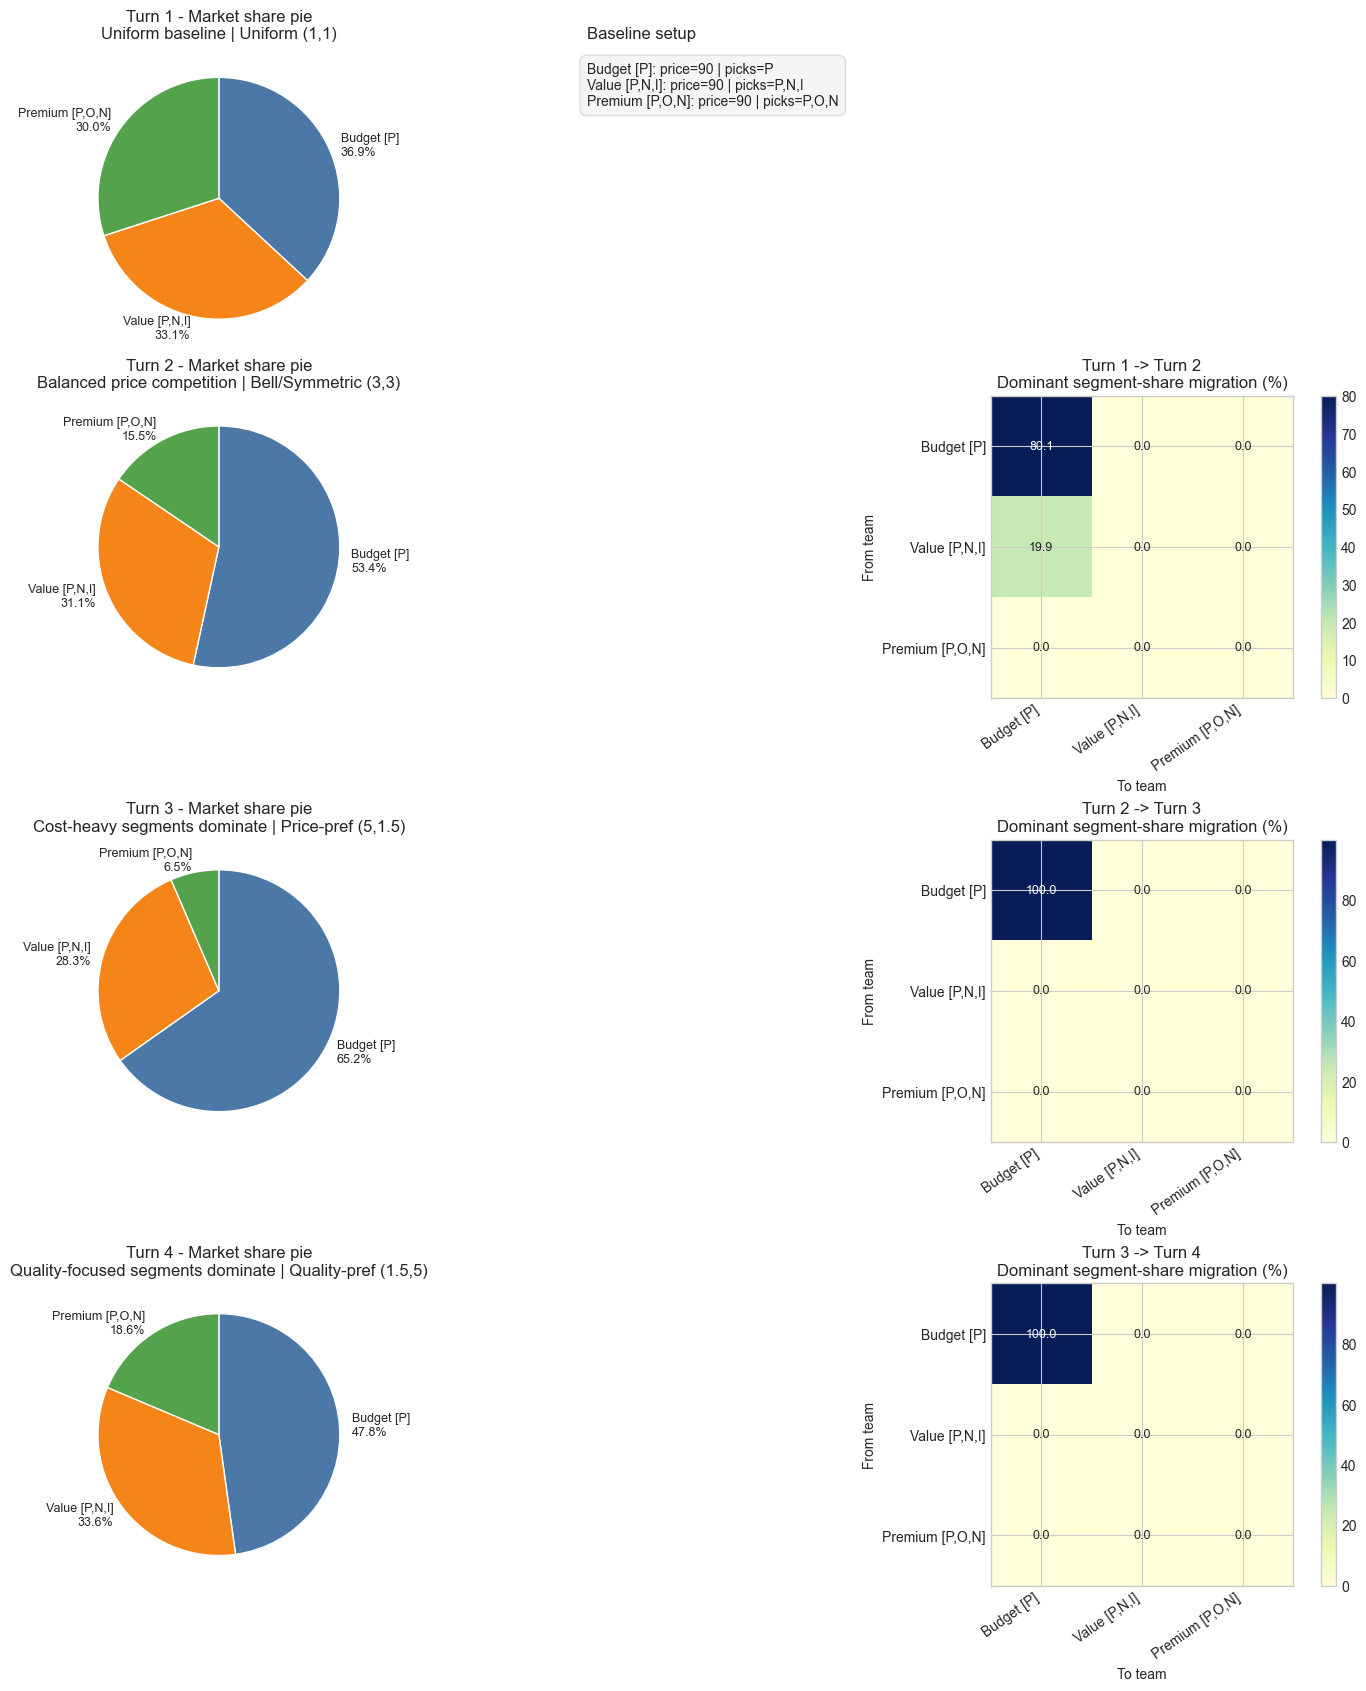

In [56]:
team_order = list(df_turn_summary['team'].drop_duplicates())
turn_order = (
    df_turn_summary[['turn_number', 'turn', 'scenario', 'distribution_name']]
    .drop_duplicates()
    .sort_values('turn_number')
)

fig, axes = plt.subplots(len(turn_order), 2, figsize=(15, 4.2 * len(turn_order)), constrained_layout=True)
if len(turn_order) == 1:
    axes = np.array([axes])

for row_idx, turn_row in enumerate(turn_order.itertuples(index=False)):
    turn = turn_row.turn
    pie_ax = axes[row_idx, 0]
    transfer_ax = axes[row_idx, 1]

    turn_df = (
        df_turn_summary[df_turn_summary['turn'] == turn]
        .set_index('team')
        .reindex(team_order)
        .fillna(0)
    )
    shares = turn_df['demand_share_pct']
    colors = [TEAM_COLORS.get(team, '#999999') for team in team_order]
    pie_ax.pie(
        shares,
        labels=[team + chr(10) + f"{value:.1f}%" for team, value in shares.items()],
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
        textprops={'fontsize': 9},
    )
    pie_ax.set_title(f"{turn} - Market share pie" + chr(10) + f"{turn_row.scenario} | {turn_row.distribution_name}")

    if row_idx == 0:
        info = turn_df.reset_index()[['team', 'price', 'picks']]
        transfer_ax.axis('off')
        transfer_ax.set_title('Baseline setup', loc='left')
        text_lines = [
            f"{r.team}: price={int(r.price)} | picks={r.picks}"
            for r in info.itertuples(index=False)
        ]
        transfer_ax.text(
            0.0, 0.95,
            chr(10).join(text_lines),
            va='top', ha='left', fontsize=10,
            bbox={'facecolor': '#f5f5f5', 'edgecolor': '#dddddd', 'boxstyle': 'round,pad=0.5'},
        )
    else:
        prev_turn = turn_order.iloc[row_idx - 1]['turn']
        transition_label = f'{prev_turn} -> {turn}'
        matrix = (
            df_turn_transitions[df_turn_transitions['transition'] == transition_label]
            .pivot_table(index='from_team', columns='to_team', values='segment_weight_pct', aggfunc='sum')
            .reindex(index=team_order, columns=team_order, fill_value=0)
        )
        im = transfer_ax.imshow(matrix.values, cmap='YlGnBu')
        transfer_ax.set_xticks(range(len(team_order)))
        transfer_ax.set_xticklabels(team_order, rotation=35, ha='right')
        transfer_ax.set_yticks(range(len(team_order)))
        transfer_ax.set_yticklabels(team_order)
        transfer_ax.set_xlabel('To team')
        transfer_ax.set_ylabel('From team')
        transfer_ax.set_title(transition_label + chr(10) + 'Dominant segment-share migration (%)')
        for i in range(len(team_order)):
            for j in range(len(team_order)):
                transfer_ax.text(
                    j, i, f"{matrix.iloc[i, j]:.1f}",
                    ha='center', va='center', fontsize=9,
                    color='white' if matrix.iloc[i, j] > matrix.values.max() * 0.5 else '#222222',
                )
        fig.colorbar(im, ax=transfer_ax, fraction=0.046, pad=0.04)

plt.show()


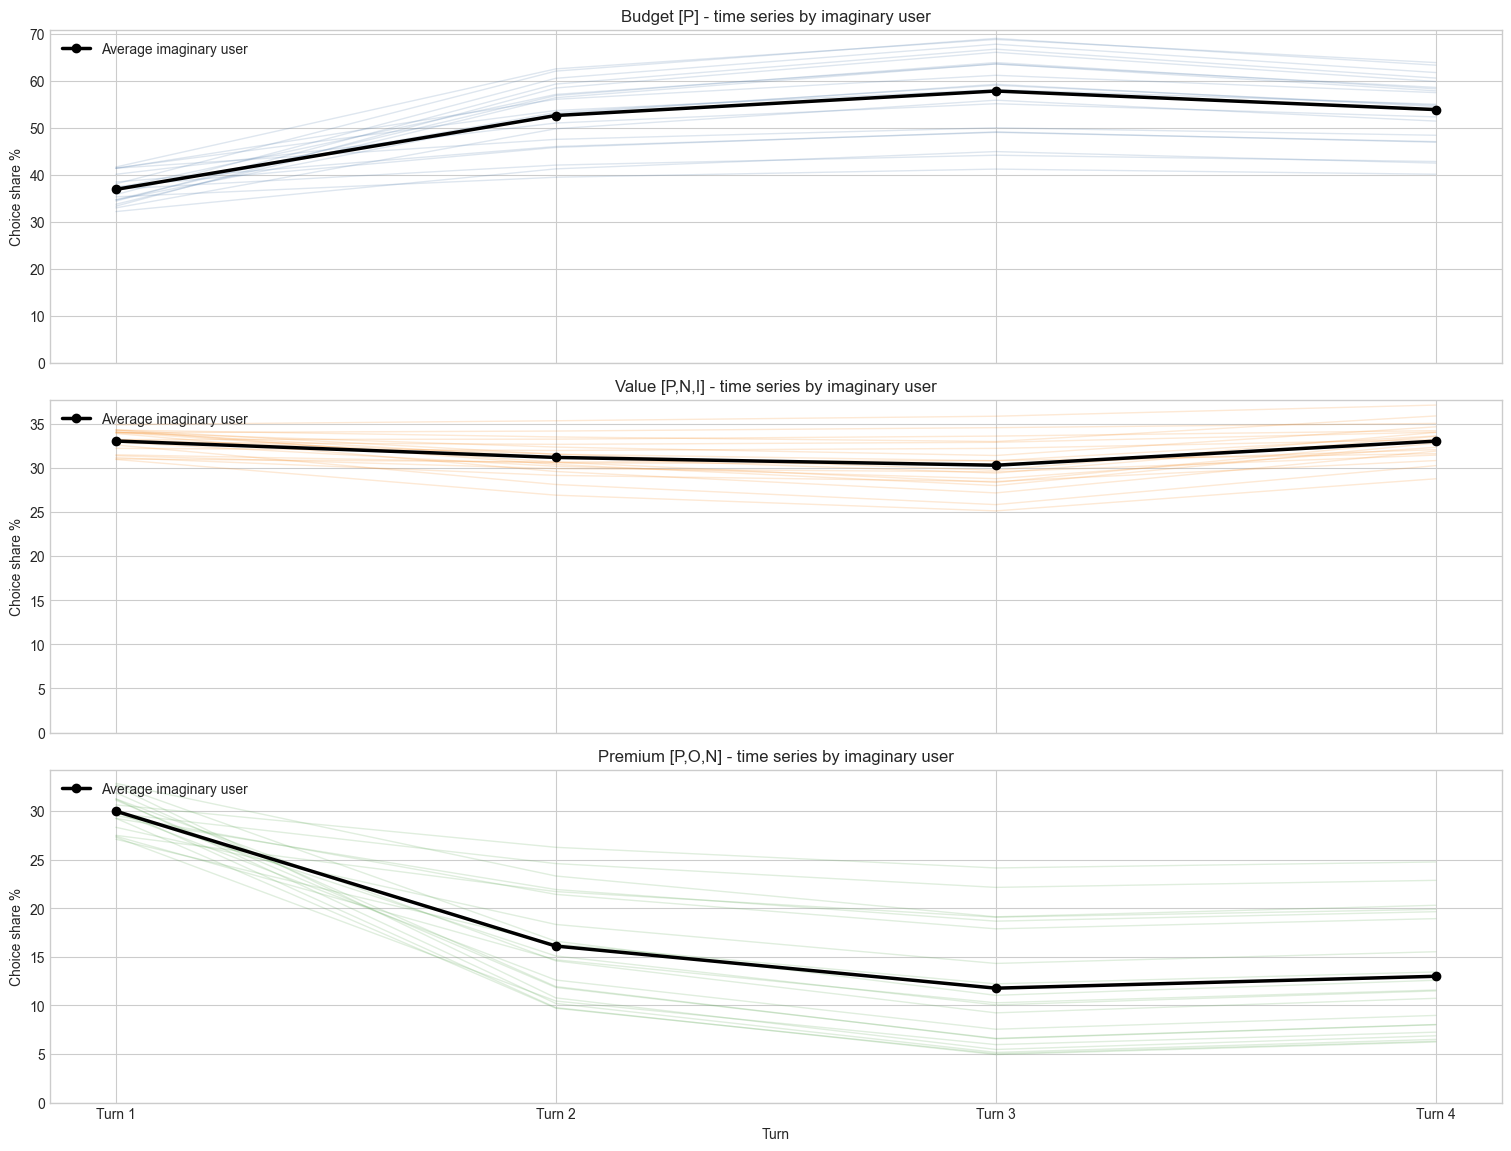

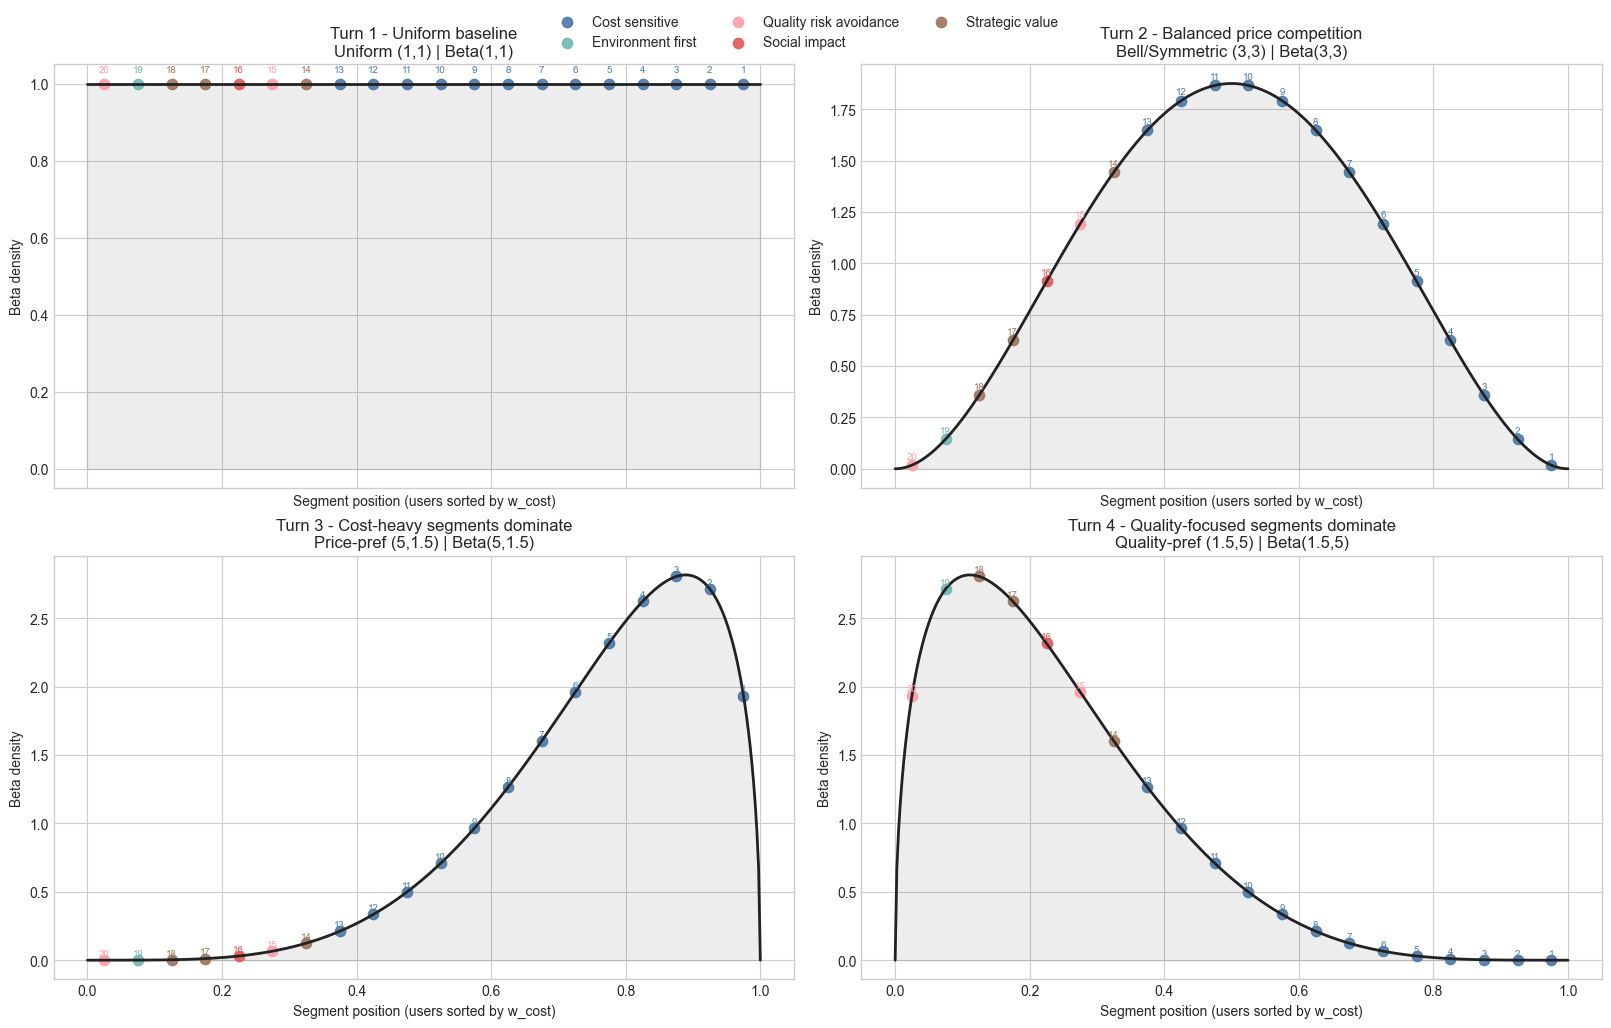

In [57]:
team_order = list(df_turn_summary['team'].drop_duplicates())
turn_ticks = turn_order['turn_number'].tolist()
turn_labels = turn_order['turn'].tolist()

fig, axes = plt.subplots(len(team_order), 1, figsize=(15, 3.8 * len(team_order)), sharex=True, constrained_layout=True)
if len(team_order) == 1:
    axes = [axes]

for ax, team in zip(axes, team_order):
    team_df = (
        df_turn_allocations[df_turn_allocations['team'] == team]
        .sort_values(['segment_rank', 'turn_number'])
    )
    color = TEAM_COLORS.get(team, '#666666')
    for segment_id, seg_df in team_df.groupby('segment_id'):
        ax.plot(
            seg_df['turn_number'],
            seg_df['team_segment_share_pct'],
            color=color,
            alpha=0.18,
            linewidth=1,
        )
    avg_line = team_df.groupby('turn_number', as_index=True)['team_segment_share_pct'].mean()
    ax.plot(avg_line.index, avg_line.values, color='black', linewidth=2.5, marker='o', label='Average imaginary user')
    ax.set_ylabel('Choice share %')
    ax.set_title(f'{team} - time series by imaginary user')
    ax.legend(loc='upper left')
    ax.set_ylim(bottom=0)

axes[-1].set_xticks(turn_ticks)
axes[-1].set_xticklabels(turn_labels)
axes[-1].set_xlabel('Turn')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, constrained_layout=True)
axes = axes.flatten()
legend_handles = {}

for ax, turn_row in zip(axes, turn_order.itertuples(index=False)):
    seg_df = (
        df_turn_segments[df_turn_segments['turn'] == turn_row.turn]
        .sort_values('segment_position')
        .copy()
    )
    density = BetaDensity(seg_df['beta_alpha'].iloc[0], seg_df['beta_beta'].iloc[0])
    x_grid, y_grid = density.sample_grid(400)
    ax.plot(x_grid, y_grid, color='#222222', linewidth=2)
    ax.fill_between(x_grid, 0, y_grid, color='#222222', alpha=0.08)

    for pref, pref_df in seg_df.groupby('dominant_preference'):
        color = PREFERENCE_COLORS.get(pref, '#888888')
        scatter = ax.scatter(
            pref_df['segment_position'],
            pref_df['density_raw'],
            s=55,
            color=color,
            alpha=0.9,
            label=pref,
        )
        legend_handles[pref] = scatter
        for row in pref_df.itertuples(index=False):
            ax.text(row.segment_position, row.density_raw + 0.03, str(row.segment_id),
                    fontsize=7, ha='center', color=color)

    ax.set_title(
        f"{turn_row.turn} - {turn_row.scenario}" + chr(10) +
        f"{seg_df['distribution_name'].iloc[0]} | {seg_df['distribution'].iloc[0]}"
    )
    ax.set_xlabel('Segment position (users sorted by w_cost)')
    ax.set_ylabel('Beta density')

for extra_ax in axes[len(turn_order):]:
    extra_ax.axis('off')

fig.legend(
    legend_handles.values(),
    legend_handles.keys(),
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
)
plt.show()


## Export to Excel

In [58]:
OUTPUT_PATH = Path('market_simulation_results.xlsx')

# Prepare extra pivot sheets
pivot_exp1_profit = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='profit_total', aggfunc='first').round(1)
pivot_exp1_utility = df_exp1[df_exp1['feasible']].pivot_table(
    index='set', columns='price', values='utility_total', aggfunc='first').round(3)

pivot_exp2_profit = df_exp2[df_exp2['feasible']].pivot_table(
    index='beta_config', columns=['set','price'], values='profit_total', aggfunc='first').round(1)

a_demand = df_exp3[df_exp3['team']=='TeamA [P,O,N]'].pivot_table(
    index='price_A', columns='price_B', values='demand_share_pct', aggfunc='first').round(1)
a_profit = df_exp3[df_exp3['team']=='TeamA [P,O,N]'].pivot_table(
    index='price_A', columns='price_B', values='realized_profit', aggfunc='first').round(0)
b_profit = df_exp3[df_exp3['team']=='TeamB [P,N,I]'].pivot_table(
    index='price_A', columns='price_B', values='realized_profit', aggfunc='first').round(0)

delta_share = df_exp6[df_exp6['beta_config']=='Bell(3,3)'].pivot_table(
    index='delta', columns='team', values='demand_share_pct', aggfunc='first').round(1)

transfer_pivot = df_turn_transitions.pivot_table(
    index=['transition', 'from_team'], columns='to_team', values='segment_weight_pct', aggfunc='sum'
).round(2)

user_time_series = df_turn_allocations.pivot_table(
    index=['segment_id', 'user_id', 'dominant_preference'],
    columns=['turn', 'team'],
    values='team_segment_share_pct',
    aggfunc='first',
).round(2)

with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:
    # Raw data
    df_exp1.to_excel(writer, sheet_name='E1_SingleTeam_Raw', index=False)
    df_exp2.to_excel(writer, sheet_name='E2_BetaEffect_Raw', index=False)
    df_exp3.to_excel(writer, sheet_name='E3_PriceWar_Raw', index=False)
    df_exp4.to_excel(writer, sheet_name='E4_BetaSweep_Raw', index=False)
    df_exp5.to_excel(writer, sheet_name='E5_ThreeTeam_Raw', index=False)
    df_exp6.to_excel(writer, sheet_name='E6_Delta_Raw', index=False)
    df_exp6b.to_excel(writer, sheet_name='E6b_PriceXDelta_Raw', index=False)
    df_turn_summary.to_excel(writer, sheet_name='V1_TurnSummary', index=False)
    df_turn_allocations.to_excel(writer, sheet_name='V1_TurnAlloc_Raw', index=False)
    df_turn_segments.to_excel(writer, sheet_name='V1_TurnSegments', index=False)
    df_turn_transitions.to_excel(writer, sheet_name='V1_Transfers_Raw', index=False)
    # Pivot tables
    pivot_exp1_profit.to_excel(writer, sheet_name='E1_Profit_Pivot')
    pivot_exp1_utility.to_excel(writer, sheet_name='E1_Utility_Pivot')
    pivot_exp2_profit.to_excel(writer, sheet_name='E2_Beta_Profit_Pivot')
    a_demand.to_excel(writer, sheet_name='E3_TeamA_Demand_Pivot')
    a_profit.to_excel(writer, sheet_name='E3_TeamA_Profit_Pivot')
    b_profit.to_excel(writer, sheet_name='E3_TeamB_Profit_Pivot')
    delta_share.to_excel(writer, sheet_name='E6_Delta_Demand_Pivot')
    pivot6b.to_excel(writer, sheet_name='E6b_PriceXDelta_Pivot')
    transfer_pivot.to_excel(writer, sheet_name='V1_Transfers_Pivot')
    user_time_series.to_excel(writer, sheet_name='V1_User_TimeSeries')

print(f'Saved -> {OUTPUT_PATH.resolve()}')
print(f'Total rows across all experiments: {sum(len(d) for d in [df_exp1,df_exp2,df_exp3,df_exp4,df_exp5,df_exp6,df_exp6b])}')


Saved -> C:\Users\LENOVO\Desktop\Asistan\Arya Phone\arya_fullstack_app\server\tests\market_simulation_results.xlsx
Total rows across all experiments: 460


## Quick Summary
Key findings printed for fast review.

In [59]:
print('='*60)
print('SIMULATION SUMMARY')
print('='*60)

print()
print('--- Feasibility check ---')
for sname, picks in SUPPLIER_SETS.items():
    a = avg_attrs(picks)
    feasible = is_feasible(picks)
    print(f"  {sname:12s} env={a.get('avg_env',0):.2f} social={a.get('avg_social',0):.2f} cost={a.get('avg_cost',0):.2f}  {'FEASIBLE' if feasible else 'INFEASIBLE'}")

print()
print('--- Exp 1: Best single-team profit @ default Beta(3,3) ---')
best1 = df_exp1[df_exp1['feasible']].sort_values('profit_total', ascending=False)
for _, r in best1.head(5).iterrows():
    print(f"  {r['set']:12s} @ price={r['price']:3.0f}  profit={r['profit_total']:8.1f}  utility={r['utility_total']:.2f}")

print()
print('--- Exp 3: Nash equilibrium hint (highest combined profit) ---')
exp3_combined = df_exp3.groupby(['price_A','price_B'])['realized_profit'].sum().reset_index()
best3 = exp3_combined.sort_values('realized_profit', ascending=False).head(5)
for _, r in best3.iterrows():
    print(f"  A={r['price_A']:3.0f} vs B={r['price_B']:3.0f}  combined_profit={r['realized_profit']:.0f}")

print()
print('--- Exp 6: Effect of delta on market share spread (Bell beta) ---')
for delta in [0.01, 0.10, 0.50]:
    sub = df_exp6[(df_exp6['delta']==delta) & (df_exp6['beta_config']=='Bell(3,3)')]
    rng = sub['demand_share_pct'].max() - sub['demand_share_pct'].min()
    print(f"  delta={delta:.2f}  share spread={rng:.1f}pp  (min={sub['demand_share_pct'].min():.1f}% max={sub['demand_share_pct'].max():.1f}%)")

print()
print('--- Visualization turns: round leaders ---')
turn_leaders = (
    df_turn_summary.sort_values(['turn_number', 'demand_share_pct'], ascending=[True, False])
    .groupby('turn', as_index=False)
    .head(1)
)
for _, r in turn_leaders.iterrows():
    print(f"  {r['turn']}: {r['team']} leads with {r['demand_share_pct']:.1f}% ({r['distribution_name']})")

print()
print('--- Biggest dominant-share migrations ---')
share_moves = (
    df_turn_transitions[df_turn_transitions['is_switch']]
    .groupby(['transition', 'from_team', 'to_team'], as_index=False)['segment_weight_pct']
    .sum()
    .sort_values('segment_weight_pct', ascending=False)
    .head(5)
)
for _, r in share_moves.iterrows():
    print(f"  {r['transition']}: {r['segment_weight_pct']:.1f}% segment weight moved {r['from_team']} -> {r['to_team']}")

print()
print('All results saved to: market_simulation_results.xlsx')


SIMULATION SUMMARY

--- Feasibility check ---
  [P]          env=2.46 social=1.58 cost=1.13  FEASIBLE
  [P,O]        env=1.97 social=2.97 cost=1.64  FEASIBLE
  [P,O,N]      env=2.50 social=2.32 cost=2.76  FEASIBLE
  [P,N]        env=3.02 social=1.29 cost=3.07  INFEASIBLE
  [P,N,I]      env=2.43 social=2.07 cost=3.07  FEASIBLE

--- Exp 1: Best single-team profit @ default Beta(3,3) ---
  [P]          @ price=140  profit=  2573.4  utility=45.07
  [P,O]        @ price=140  profit=  2471.6  utility=42.09
  [P]          @ price=130  profit=  2373.4  utility=45.07
  [P,O]        @ price=130  profit=  2271.6  utility=42.09
  [P,O,N]      @ price=140  profit=  2247.8  utility=40.62

--- Exp 3: Nash equilibrium hint (highest combined profit) ---
  A=130 vs B=130  combined_profit=2016
  A=115 vs B=130  combined_profit=1846
  A=130 vs B=115  combined_profit=1818
  A=115 vs B=115  combined_profit=1716
  A=100 vs B=130  combined_profit=1607

--- Exp 6: Effect of delta on market share spread (Bell b